# MLPerf-Style Mini Benchmark for CPU, GPU, and TPU on GCP

This notebook is an educational mini benchmark. It is not an official MLPerf submission, does not use the official MLPerf rules, and should not be used to rank vendors or hardware platforms.

The goal is to help students compare CPU-only, NVIDIA GPU, and Google Cloud TPU runtimes in a controlled, budget-conscious way. The notebook benchmarks only the runtime where it is currently running. To compare CPU, GPU, and TPU, run the same notebook on each runtime and combine the CSV result files.

The workload is inspired by MLPerf image-classification training and inference, but it uses Fashion-MNIST and a small CNN so that the experiment can fit within a small GCP credit budget.

## Cost Warning and Recommended Run Order

This notebook does not launch GCP resources. It only uses the CPU, GPU, or TPU attached to the current Jupyter runtime.

Accelerator runtimes can still consume GCP credits quickly, especially NVIDIA H100 instances. Use this recommended order:

1. Run the notebook on CPU first to verify correctness.
2. Run a small TPU v5e experiment next, using the default short iteration counts.
3. Run H100 only after the CPU and TPU pipeline works.
4. Keep H100 batch sizes and measured iterations small.
5. Stop or delete expensive GPU and TPU resources immediately after the experiment.
6. Save CSV results so you do not need to repeat expensive runs.

The first code cell exposes `BENCHMARK_PROFILE`. Use `quick` for the first validation run, `expanded` for a more useful accelerator comparison, and `accelerator_stress` only after the notebook has already run successfully on that runtime.

Warning: This notebook is intentionally small. Mini benchmark results should not be overgeneralized to full-scale MLPerf results.

In [1]:
import csv
import datetime as dt
import gc
import gzip
import json
import math
import os
import pathlib
import platform
import statistics
import struct
import subprocess
import sys
import time
import traceback
import urllib.request
import uuid
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np

try:
    import jax
    import jax.numpy as jnp
except ImportError as exc:
    raise ImportError(
        "This notebook requires JAX. Install the JAX build that matches your CPU, GPU, or TPU runtime."
    ) from exc

# Use a benchmark profile to control cost and runtime.
# quick: safest first run on CPU or a new runtime.
# expanded: better accelerator utilization while still staying educational.
# accelerator_stress: larger sweep for H100/TPU v5e after the pipeline is validated.
BENCHMARK_PROFILE = "accelerator_stress"

BENCHMARK_PROFILES = {
    "quick": {
        "batch_sizes": [1, 8, 16, 32, 64, 128],
        "train_warmup_steps": 3,
        "train_measure_steps": 10,
        "inference_warmup_steps": 3,
        "inference_measure_steps": 20,
        "max_train_examples": 8192,
        "max_test_examples": 2048,
    },
    "expanded": {
        "batch_sizes": [1, 8, 16, 32, 64, 128, 256, 512, 1024],
        "train_warmup_steps": 5,
        "train_measure_steps": 30,
        "inference_warmup_steps": 5,
        "inference_measure_steps": 75,
        "max_train_examples": 32768,
        "max_test_examples": 8192,
    },
    "accelerator_stress": {
        "batch_sizes": [1, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096],
        "train_warmup_steps": 10,
        "train_measure_steps": 100,
        "inference_warmup_steps": 10,
        "inference_measure_steps": 250,
        "max_train_examples": 60000,
        "max_test_examples": 10000,
    },
}

if BENCHMARK_PROFILE not in BENCHMARK_PROFILES:
    raise ValueError(f"Unknown BENCHMARK_PROFILE={BENCHMARK_PROFILE!r}")

PROFILE_CONFIG = BENCHMARK_PROFILES[BENCHMARK_PROFILE]

# Keep the run controlled for GCP experiments. Increase the profile only after a quick run succeeds.
RUN_ID = dt.datetime.now(dt.timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + uuid.uuid4().hex[:8]
RANDOM_SEED = 7
DATASET_NAME = "fashion_mnist"
MODEL_NAME = "SmallJAXCNN"
FRAMEWORK_NAME = "JAX/XLA"

# Use float32 for the default apples-to-apples educational baseline.
# For a follow-up accelerator-focused experiment, students can test bfloat16 carefully and label it clearly.
COMPUTE_DTYPE = jnp.float32
NUM_CLASSES = 10

BATCH_SIZES = PROFILE_CONFIG["batch_sizes"]
TRAIN_WARMUP_STEPS = PROFILE_CONFIG["train_warmup_steps"]
TRAIN_MEASURE_STEPS = PROFILE_CONFIG["train_measure_steps"]
INFERENCE_WARMUP_STEPS = PROFILE_CONFIG["inference_warmup_steps"]
INFERENCE_MEASURE_STEPS = PROFILE_CONFIG["inference_measure_steps"]
LEARNING_RATE = 0.02

MAX_TRAIN_EXAMPLES = PROFILE_CONFIG["max_train_examples"]
MAX_TEST_EXAMPLES = PROFILE_CONFIG["max_test_examples"]
ALLOW_DATASET_DOWNLOAD = True
ALLOW_SYNTHETIC_FALLBACK = True
DATA_ROOT = pathlib.Path("data/fashion_mnist")

RUN_TRAINING_BENCHMARK = True
RUN_INFERENCE_BENCHMARK = True

TRAINING_RESULTS_PATH = pathlib.Path("benchmark_results_training.csv")
INFERENCE_RESULTS_PATH = pathlib.Path("benchmark_results_inference.csv")
ALL_RESULTS_PATH = pathlib.Path("benchmark_results_all.csv")

RESULT_COLUMNS = [
    "timestamp",
    "run_id",
    "device_type",
    "hardware_model",
    "accelerator_count",
    "framework",
    "framework_version",
    "task_type",
    "dataset",
    "model",
    "batch_size",
    "compile_time_seconds",
    "warm_up_time_seconds",
    "average_latency_ms",
    "median_latency_ms",
    "throughput_samples_per_second",
    "total_wall_time_seconds",
    "number_of_iterations",
    "first_run_overhead_seconds",
    "memory_used_mb",
    "numeric_precision",
    "hardware_generation_note",
    "status",
    "notes",
]

print(f"Run ID: {RUN_ID}")
print(f"Python: {sys.version.split()[0]}")
print(f"JAX: {jax.__version__}")
print(f"Default JAX backend: {jax.default_backend()}")
print(f"Benchmark profile: {BENCHMARK_PROFILE}")
print(f"Batch sizes: {BATCH_SIZES}")
print(f"Training warm-up/measured steps: {TRAIN_WARMUP_STEPS}/{TRAIN_MEASURE_STEPS}")
print(f"Inference warm-up/measured steps: {INFERENCE_WARMUP_STEPS}/{INFERENCE_MEASURE_STEPS}")

Run ID: 20260606T194444Z-d9203666
Python: 3.12.13
JAX: 0.7.2
Default JAX backend: cpu
Benchmark profile: accelerator_stress
Batch sizes: [1, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
Training warm-up/measured steps: 10/100
Inference warm-up/measured steps: 10/250


## Environment Detection

This section records the exact runtime context. Hardware labels matter: H100 is a generation-aligned GPU baseline for TPU v5e, A100 is a practical fallback baseline, and P100/V100 should be treated as historical or availability-driven school baselines.

In [2]:
def run_command(args: List[str], timeout: float = 5.0) -> str:
    """Run a system command and return stdout, or an empty string if unavailable."""
    try:
        completed = subprocess.run(args, capture_output=True, text=True, timeout=timeout, check=False)
        return completed.stdout.strip()
    except Exception:
        return ""


def parse_lscpu_model(lscpu_text: str) -> str:
    for line in lscpu_text.splitlines():
        if line.lower().startswith("model name:"):
            return line.split(":", 1)[1].strip()
    return ""


def detect_cpu_info() -> Dict[str, Any]:
    lscpu_text = run_command(["lscpu"])
    model = parse_lscpu_model(lscpu_text)
    if not model:
        model = run_command(["sysctl", "-n", "machdep.cpu.brand_string"])
    if not model:
        model = platform.processor() or platform.machine() or "Unknown CPU"
    return {
        "model": model,
        "machine": platform.machine(),
        "processor": platform.processor(),
        "lscpu": lscpu_text[:4000],
    }


def detect_gpu_info() -> Dict[str, Any]:
    query = ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"]
    raw = run_command(query)
    gpus = []
    for line in raw.splitlines():
        parts = [part.strip() for part in line.split(",")]
        if parts and parts[0]:
            gpus.append({"name": parts[0], "memory_total": parts[1] if len(parts) > 1 else "unknown"})
    return {"available": bool(gpus), "count": len(gpus), "gpus": gpus, "nvidia_smi": raw}


def get_gcp_metadata(path: str, timeout: float = 0.35) -> str:
    url = "http://metadata.google.internal/computeMetadata/v1/" + path
    request = urllib.request.Request(url, headers={"Metadata-Flavor": "Google"})
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response:
            return response.read().decode("utf-8")
    except Exception:
        return ""


def detect_cloud_info() -> Dict[str, str]:
    return {
        "gcp_project_id": get_gcp_metadata("project/project-id"),
        "gcp_zone": get_gcp_metadata("instance/zone"),
        "gcp_machine_type": get_gcp_metadata("instance/machine-type"),
        "hostname": platform.node(),
        "platform": platform.platform(),
    }


def detect_tpu_info() -> Dict[str, Any]:
    tpu_devices = [device for device in jax.devices() if device.platform == "tpu"]
    env_keys = [
        "TPU_NAME",
        "TPU_ACCELERATOR_TYPE",
        "TPU_WORKER_ID",
        "CLOUD_TPU_TASK_ID",
        "COLAB_TPU_ADDR",
        "JAX_PLATFORMS",
    ]
    env = {key: os.environ.get(key, "") for key in env_keys if os.environ.get(key, "")}
    platform_versions = sorted({getattr(device, "platform_version", "") for device in tpu_devices if getattr(device, "platform_version", "")})
    return {
        "available": bool(tpu_devices),
        "count": len(tpu_devices),
        "devices": [str(device) for device in tpu_devices],
        "platform_versions": platform_versions,
        "env": env,
    }


def classify_hardware_generation(device_type: str, hardware_model: str) -> str:
    text = hardware_model.lower()
    if device_type == "GPU" and "h100" in text:
        return "H100: generation-aligned GPU baseline for TPU v5e experiments."
    if device_type == "GPU" and "a100" in text:
        return "A100: practical fallback GPU baseline, not generation-aligned with TPU v5e."
    if device_type == "GPU" and ("v100" in text or "p100" in text):
        return "P100/V100: historical or availability-driven baseline, not generation-aligned."
    if device_type == "TPU" and "v5" in text:
        return "TPU v5 family: target TPU generation for this mini benchmark."
    if device_type == "TPU":
        return "TPU detected: label the exact TPU generation before interpreting results."
    if device_type == "CPU":
        return "CPU baseline: useful for correctness and scale reference, not an accelerator peer."
    return "Hardware generation could not be classified automatically."


def detect_environment() -> Dict[str, Any]:
    devices = jax.devices()
    default_backend = jax.default_backend()
    device_type = default_backend.upper()
    cpu_info = detect_cpu_info()
    gpu_info = detect_gpu_info()
    tpu_info = detect_tpu_info()
    cloud_info = detect_cloud_info()

    if default_backend == "gpu" and gpu_info["gpus"]:
        hardware_model = "; ".join(gpu["name"] + " (" + gpu["memory_total"] + ")" for gpu in gpu_info["gpus"])
    elif default_backend == "tpu":
        env_type = tpu_info["env"].get("TPU_ACCELERATOR_TYPE", "")
        versions = "; ".join(tpu_info["platform_versions"])
        hardware_model = env_type or versions or "TPU detected by JAX"
    else:
        hardware_model = cpu_info["model"]

    accelerator_count = len([device for device in devices if device.platform in ("gpu", "tpu")])
    generation_note = classify_hardware_generation(device_type, hardware_model)

    return {
        "python_version": sys.version.split()[0],
        "jax_version": jax.__version__,
        "default_backend": default_backend,
        "device_type": device_type,
        "hardware_model": hardware_model,
        "accelerator_count": accelerator_count,
        "jax_devices": [str(device) for device in devices],
        "cpu_info": cpu_info,
        "gpu_info": gpu_info,
        "tpu_info": tpu_info,
        "cloud_info": cloud_info,
        "hardware_generation_note": generation_note,
    }


ENV = detect_environment()
print(json.dumps(ENV, indent=2))

{
  "python_version": "3.12.13",
  "jax_version": "0.7.2",
  "default_backend": "cpu",
  "device_type": "CPU",
  "hardware_model": "Intel(R) Xeon(R) CPU @ 2.20GHz",
  "accelerator_count": 0,
  "jax_devices": [
    "TFRT_CPU_0"
  ],
  "cpu_info": {
    "model": "Intel(R) Xeon(R) CPU @ 2.20GHz",
    "machine": "x86_64",
    "processor": "x86_64",
    "lscpu": "Architecture:                            x86_64\nCPU op-mode(s):                          32-bit, 64-bit\nAddress sizes:                           46 bits physical, 48 bits virtual\nByte Order:                              Little Endian\nCPU(s):                                  2\nOn-line CPU(s) list:                     0,1\nVendor ID:                               GenuineIntel\nModel name:                              Intel(R) Xeon(R) CPU @ 2.20GHz\nCPU family:                              6\nModel:                                   79\nThread(s) per core:                      2\nCore(s) per socket:                      1\nSocket

## Dataset Choice

Official MLPerf image-classification workloads commonly use much larger datasets and models. That is not appropriate for a small educational experiment with about $300 of GCP credit.

This notebook uses Fashion-MNIST as a budget-conscious image-classification proxy. It is small, quick to download, easy to explain, and still exercises the same broad training and inference pipeline shape: image batches, convolution, dense layers, loss computation, backpropagation, and batched prediction.

If Fashion-MNIST cannot be downloaded, the notebook falls back to a small synthetic image-like dataset and records that fact in the result notes.

In [3]:
FASHION_MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

FASHION_MNIST_URL_BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"


def download_file(url: str, destination: pathlib.Path) -> None:
    destination.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=90) as response:
        destination.write_bytes(response.read())


def ensure_fashion_mnist_files(data_root: pathlib.Path) -> None:
    if not ALLOW_DATASET_DOWNLOAD:
        raise RuntimeError("Dataset download is disabled by ALLOW_DATASET_DOWNLOAD=False.")
    for filename in FASHION_MNIST_FILES.values():
        path = data_root / filename
        if not path.exists():
            print(f"Downloading {filename}...")
            download_file(FASHION_MNIST_URL_BASE + filename, path)


def read_idx_images(path: pathlib.Path) -> np.ndarray:
    with gzip.open(path, "rb") as handle:
        magic, count, rows, cols = struct.unpack(">IIII", handle.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image file magic number: {magic}")
        data = np.frombuffer(handle.read(), dtype=np.uint8)
    images = data.reshape(count, rows, cols, 1).astype(np.float32) / 255.0
    return images


def read_idx_labels(path: pathlib.Path) -> np.ndarray:
    with gzip.open(path, "rb") as handle:
        magic, count = struct.unpack(">II", handle.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label file magic number: {magic}")
        labels = np.frombuffer(handle.read(), dtype=np.uint8)
    return labels.astype(np.int32)


def shuffle_and_limit(images: np.ndarray, labels: np.ndarray, limit: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(images))[:limit]
    return images[indices], labels[indices]


def load_fashion_mnist_sample() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, str]]:
    ensure_fashion_mnist_files(DATA_ROOT)
    x_train = read_idx_images(DATA_ROOT / FASHION_MNIST_FILES["train_images"])
    y_train = read_idx_labels(DATA_ROOT / FASHION_MNIST_FILES["train_labels"])
    x_test = read_idx_images(DATA_ROOT / FASHION_MNIST_FILES["test_images"])
    y_test = read_idx_labels(DATA_ROOT / FASHION_MNIST_FILES["test_labels"])
    x_train, y_train = shuffle_and_limit(x_train, y_train, MAX_TRAIN_EXAMPLES, RANDOM_SEED)
    x_test, y_test = shuffle_and_limit(x_test, y_test, MAX_TEST_EXAMPLES, RANDOM_SEED + 1)
    info = {
        "dataset": "Fashion-MNIST sample",
        "notes": "Downloaded Fashion-MNIST IDX files and used a small shuffled subset.",
    }
    return x_train, y_train, x_test, y_test, info


def make_synthetic_image_dataset() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, str]]:
    rng = np.random.default_rng(RANDOM_SEED)

    def make_split(count: int) -> Tuple[np.ndarray, np.ndarray]:
        labels = rng.integers(0, NUM_CLASSES, size=count, dtype=np.int32)
        images = rng.normal(loc=0.03, scale=0.02, size=(count, 28, 28, 1)).astype(np.float32)
        for row_index, label in enumerate(labels):
            block_row = 2 + int(label // 5) * 12
            block_col = 2 + int(label % 5) * 5
            images[row_index, block_row:block_row + 6, block_col:block_col + 4, 0] += 0.8
        return np.clip(images, 0.0, 1.0), labels

    x_train, y_train = make_split(MAX_TRAIN_EXAMPLES)
    x_test, y_test = make_split(MAX_TEST_EXAMPLES)
    info = {
        "dataset": "Synthetic image-like sample",
        "notes": "Fashion-MNIST download failed or was disabled; using synthetic class-coded images.",
    }
    return x_train, y_train, x_test, y_test, info


def load_dataset() -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict[str, str]]:
    try:
        if DATASET_NAME != "fashion_mnist":
            raise ValueError(f"Unsupported DATASET_NAME={DATASET_NAME}")
        return load_fashion_mnist_sample()
    except Exception as exc:
        if not ALLOW_SYNTHETIC_FALLBACK:
            raise
        print("Dataset load failed; falling back to synthetic data.")
        print(str(exc))
        return make_synthetic_image_dataset()


X_TRAIN, Y_TRAIN, X_TEST, Y_TEST, DATASET_INFO = load_dataset()
print(DATASET_INFO)
print(f"Train shape: {X_TRAIN.shape}, labels: {Y_TRAIN.shape}")
print(f"Test shape: {X_TEST.shape}, labels: {Y_TEST.shape}")

{'dataset': 'Fashion-MNIST sample', 'notes': 'Downloaded Fashion-MNIST IDX files and used a small shuffled subset.'}
Train shape: (60000, 28, 28, 1), labels: (60000,)
Test shape: (10000, 28, 28, 1), labels: (10000,)


## Model and Benchmark Utilities

The model is a small CNN implemented directly in JAX. Avoiding Flax, Optax, TensorFlow, and PyTorch keeps the dependency surface small and makes it easier to run the same benchmark on CPU, GPU, and TPU.

Timing separates compile time, warm-up time, measured compute time, and total wall-clock time. For JAX/XLA, compile time is measured with `lower(...).compile()` when available. Latency is reported as per-batch step time; throughput is samples per second.

In [4]:
def he_normal(key: Any, shape: Tuple[int, ...], fan_in: int) -> jnp.ndarray:
    values = jax.random.normal(key, shape, dtype=COMPUTE_DTYPE)
    return values * jnp.asarray(math.sqrt(2.0 / fan_in), dtype=COMPUTE_DTYPE)


def init_model_params(key: Any) -> Dict[str, Dict[str, jnp.ndarray]]:
    keys = jax.random.split(key, 6)
    return {
        "conv1": {
            "w": he_normal(keys[0], (3, 3, 1, 16), 3 * 3 * 1),
            "b": jnp.zeros((16,), dtype=COMPUTE_DTYPE),
        },
        "conv2": {
            "w": he_normal(keys[1], (3, 3, 16, 32), 3 * 3 * 16),
            "b": jnp.zeros((32,), dtype=COMPUTE_DTYPE),
        },
        "dense1": {
            "w": he_normal(keys[2], (7 * 7 * 32, 128), 7 * 7 * 32),
            "b": jnp.zeros((128,), dtype=COMPUTE_DTYPE),
        },
        "dense2": {
            "w": he_normal(keys[3], (128, NUM_CLASSES), 128),
            "b": jnp.zeros((NUM_CLASSES,), dtype=COMPUTE_DTYPE),
        },
    }


def conv2d_nhwc(x: jnp.ndarray, w: jnp.ndarray, b: jnp.ndarray) -> jnp.ndarray:
    y = jax.lax.conv_general_dilated(
        x,
        w,
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )
    return y + b.reshape((1, 1, 1, -1))


def avg_pool_2x2(x: jnp.ndarray) -> jnp.ndarray:
    batch, height, width, channels = x.shape
    if height % 2 != 0 or width % 2 != 0:
        raise ValueError("avg_pool_2x2 expects even height and width.")
    pooled = x.reshape((batch, height // 2, 2, width // 2, 2, channels))
    return jnp.mean(pooled, axis=(2, 4))


def forward(params: Dict[str, Dict[str, jnp.ndarray]], x: jnp.ndarray) -> jnp.ndarray:
    x = x.astype(COMPUTE_DTYPE)
    x = jax.nn.relu(conv2d_nhwc(x, params["conv1"]["w"], params["conv1"]["b"]))
    x = avg_pool_2x2(x)
    x = jax.nn.relu(conv2d_nhwc(x, params["conv2"]["w"], params["conv2"]["b"]))
    x = avg_pool_2x2(x)
    x = x.reshape((x.shape[0], -1))
    x = jax.nn.relu(x @ params["dense1"]["w"] + params["dense1"]["b"])
    logits = x @ params["dense2"]["w"] + params["dense2"]["b"]
    return logits.astype(jnp.float32)


def cross_entropy_loss(logits: jnp.ndarray, labels: jnp.ndarray) -> jnp.ndarray:
    one_hot = jax.nn.one_hot(labels, NUM_CLASSES)
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1))


@jax.jit
def train_step(params: Dict[str, Dict[str, jnp.ndarray]], x: jnp.ndarray, y: jnp.ndarray, learning_rate: jnp.ndarray):
    def loss_fn(current_params):
        logits = forward(current_params, x)
        return cross_entropy_loss(logits, y)

    loss, grads = jax.value_and_grad(loss_fn)(params)
    updated = jax.tree_util.tree_map(lambda p, g: p - learning_rate * g, params, grads)
    return updated, loss


@jax.jit
def inference_step(params: Dict[str, Dict[str, jnp.ndarray]], x: jnp.ndarray) -> jnp.ndarray:
    return forward(params, x)


def block_until_ready_tree(value: Any) -> Any:
    for leaf in jax.tree_util.tree_leaves(value):
        if hasattr(leaf, "block_until_ready"):
            leaf.block_until_ready()
    return value


def make_device_batches(
    images: np.ndarray,
    labels: np.ndarray,
    batch_size: int,
    num_batches: int,
    seed: int,
) -> List[Tuple[jnp.ndarray, jnp.ndarray]]:
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(images), size=(num_batches, batch_size))
    batches = []
    for batch_indices in indices:
        x_batch = jax.device_put(images[batch_indices])
        y_batch = jax.device_put(labels[batch_indices])
        batches.append((x_batch, y_batch))
    return batches


def compile_jitted(jitted_function: Any, *args: Any) -> Tuple[Any, float, str]:
    start = time.perf_counter()
    try:
        compiled = jitted_function.lower(*args).compile()
        compile_time = time.perf_counter() - start
        return compiled, compile_time, "explicit_lower_compile"
    except AttributeError:
        # Older JAX versions may not expose lower(). In that case, the first call includes compilation.
        return jitted_function, math.nan, "first_call_includes_compile"


def short_error(exc: Exception, max_chars: int = 350) -> str:
    text = " ".join(str(exc).split())
    if len(text) > max_chars:
        return text[:max_chars] + "..."
    return text


def is_probable_oom(exc: Exception) -> bool:
    text = str(exc).lower()
    markers = ["out of memory", "oom", "resource exhausted", "allocation", "memory"]
    return any(marker in text for marker in markers)


def get_gpu_memory_used_mb() -> Optional[float]:
    raw = run_command(["nvidia-smi", "--query-gpu=memory.used", "--format=csv,noheader,nounits"], timeout=2.0)
    values = []
    for line in raw.splitlines():
        try:
            values.append(float(line.strip()))
        except ValueError:
            pass
    return max(values) if values else None


def get_process_memory_mb() -> Optional[float]:
    try:
        import psutil

        return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    except Exception:
        try:
            import resource

            usage = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            if sys.platform == "darwin":
                return usage / (1024 ** 2)
            return usage / 1024
        except Exception:
            return None


def get_memory_usage_mb() -> Optional[float]:
    if ENV["device_type"] == "GPU":
        return get_gpu_memory_used_mb()
    if ENV["device_type"] == "TPU":
        return None
    return get_process_memory_mb()


def now_iso() -> str:
    return dt.datetime.now(dt.timezone.utc).isoformat()


def base_result_row(task_type: str, batch_size: int) -> Dict[str, Any]:
    return {
        "timestamp": now_iso(),
        "run_id": RUN_ID,
        "device_type": ENV["device_type"],
        "hardware_model": ENV["hardware_model"],
        "accelerator_count": ENV["accelerator_count"],
        "framework": FRAMEWORK_NAME,
        "framework_version": jax.__version__,
        "task_type": task_type,
        "dataset": DATASET_INFO["dataset"],
        "model": MODEL_NAME,
        "batch_size": batch_size,
        "compile_time_seconds": math.nan,
        "warm_up_time_seconds": math.nan,
        "average_latency_ms": math.nan,
        "median_latency_ms": math.nan,
        "throughput_samples_per_second": math.nan,
        "total_wall_time_seconds": math.nan,
        "number_of_iterations": 0,
        "first_run_overhead_seconds": math.nan,
        "memory_used_mb": math.nan,
        "numeric_precision": str(COMPUTE_DTYPE),
        "hardware_generation_note": ENV["hardware_generation_note"],
        "status": "pending",
        "notes": DATASET_INFO["notes"],
    }


def append_results_to_csv(rows: List[Dict[str, Any]], path: pathlib.Path) -> None:
    if not rows:
        return
    write_header = not path.exists() or path.stat().st_size == 0
    with path.open("a", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=RESULT_COLUMNS, extrasaction="ignore")
        if write_header:
            writer.writeheader()
        writer.writerows(rows)


def clear_jax_caches_if_available() -> None:
    try:
        jax.clear_caches()
    except Exception:
        pass


print("Model parameter count:")
_params_preview = init_model_params(jax.random.PRNGKey(RANDOM_SEED))
_param_count = sum(int(np.prod(leaf.shape)) for leaf in jax.tree_util.tree_leaves(_params_preview))
print(_param_count)

Model parameter count:
206922


## Part 1: Training Benchmark

Warning: This cell may use billable accelerator resources. Confirm that you are running on the intended runtime and that your GCP quota and budget are appropriate before continuing.

The training benchmark compiles the JAX training step for each batch size, runs separate warm-up steps, then measures a small number of SGD steps. Failed batch sizes are recorded instead of crashing the notebook.

In [5]:
def run_training_for_batch_size(batch_size: int) -> Tuple[Dict[str, Any], Optional[Dict[str, Dict[str, jnp.ndarray]]]]:
    row = base_result_row("training", batch_size)
    params = None
    compile_time = math.nan
    first_run_time = math.nan
    try:
        total_iterations = TRAIN_WARMUP_STEPS + TRAIN_MEASURE_STEPS
        batches = make_device_batches(X_TRAIN, Y_TRAIN, batch_size, total_iterations, RANDOM_SEED + batch_size)
        params = jax.device_put(init_model_params(jax.random.PRNGKey(RANDOM_SEED)))
        learning_rate = jnp.asarray(LEARNING_RATE, dtype=jnp.float32)
        memory_before = get_memory_usage_mb()

        compiled_train_step, compile_time, compile_mode = compile_jitted(
            train_step,
            params,
            batches[0][0],
            batches[0][1],
            learning_rate,
        )

        first_start = time.perf_counter()
        params, loss = compiled_train_step(params, batches[0][0], batches[0][1], learning_rate)
        block_until_ready_tree((params, loss))
        first_run_time = time.perf_counter() - first_start

        warmup_start = time.perf_counter()
        for batch_index in range(1, TRAIN_WARMUP_STEPS):
            params, loss = compiled_train_step(params, batches[batch_index][0], batches[batch_index][1], learning_rate)
            block_until_ready_tree((params, loss))
        warmup_time = first_run_time + (time.perf_counter() - warmup_start)

        step_times = []
        measured_start = time.perf_counter()
        for batch_index in range(TRAIN_WARMUP_STEPS, total_iterations):
            step_start = time.perf_counter()
            params, loss = compiled_train_step(params, batches[batch_index][0], batches[batch_index][1], learning_rate)
            block_until_ready_tree((params, loss))
            step_times.append(time.perf_counter() - step_start)
        measured_wall = time.perf_counter() - measured_start

        average_step = statistics.mean(step_times)
        median_step = statistics.median(step_times)
        memory_after = get_memory_usage_mb()
        total_wall = (0.0 if math.isnan(compile_time) else compile_time) + warmup_time + measured_wall

        first_run_overhead = first_run_time if math.isnan(compile_time) else compile_time + first_run_time

        row.update(
            {
                "compile_time_seconds": compile_time,
                "warm_up_time_seconds": warmup_time,
                "average_latency_ms": average_step * 1000.0,
                "median_latency_ms": median_step * 1000.0,
                "throughput_samples_per_second": batch_size / average_step,
                "total_wall_time_seconds": total_wall,
                "number_of_iterations": TRAIN_MEASURE_STEPS,
                "first_run_overhead_seconds": first_run_overhead,
                "memory_used_mb": memory_after if memory_after is not None else math.nan,
                "status": "success",
                "notes": f"{DATASET_INFO['notes']} compile_mode={compile_mode}; memory_before_mb={memory_before}; memory_after_mb={memory_after}; final_loss={float(loss):.5f}",
            }
        )
        return row, params
    except Exception as exc:
        row.update(
            {
                "status": "failed_oom" if is_probable_oom(exc) else "failed",
                "notes": f"{DATASET_INFO['notes']} error={short_error(exc)}",
                "memory_used_mb": get_memory_usage_mb() or math.nan,
            }
        )
        gc.collect()
        clear_jax_caches_if_available()
        return row, None


def run_training_benchmark() -> Tuple[List[Dict[str, Any]], Optional[Dict[str, Dict[str, jnp.ndarray]]]]:
    results = []
    last_successful_params = None
    for batch_size in BATCH_SIZES:
        print(f"Training batch size {batch_size}...")
        row, params = run_training_for_batch_size(batch_size)
        results.append(row)
        if row["status"] == "success" and params is not None:
            last_successful_params = params
        print({key: row[key] for key in ["batch_size", "status", "average_latency_ms", "throughput_samples_per_second", "compile_time_seconds"]})
    return results, last_successful_params


if RUN_TRAINING_BENCHMARK:
    TRAINING_RESULTS, TRAINED_PARAMS = run_training_benchmark()
    append_results_to_csv(TRAINING_RESULTS, TRAINING_RESULTS_PATH)
    append_results_to_csv(TRAINING_RESULTS, ALL_RESULTS_PATH)
    print(f"Saved training results to {TRAINING_RESULTS_PATH} and {ALL_RESULTS_PATH}")
else:
    TRAINING_RESULTS = []
    TRAINED_PARAMS = None
    print("Training benchmark skipped by RUN_TRAINING_BENCHMARK=False")

Training batch size 1...
{'batch_size': 1, 'status': 'success', 'average_latency_ms': 2.8571214499879716, 'throughput_samples_per_second': 350.0026223961218, 'compile_time_seconds': 3.270876820999547}
Training batch size 8...
{'batch_size': 8, 'status': 'success', 'average_latency_ms': 3.917890420007097, 'throughput_samples_per_second': 2041.915199860416, 'compile_time_seconds': 1.3496578300000692}
Training batch size 16...
{'batch_size': 16, 'status': 'success', 'average_latency_ms': 5.956256540011964, 'throughput_samples_per_second': 2686.2509854163973, 'compile_time_seconds': 0.9961217870004475}
Training batch size 32...
{'batch_size': 32, 'status': 'success', 'average_latency_ms': 19.650813400057814, 'throughput_samples_per_second': 1628.431319789839, 'compile_time_seconds': 1.7500241130001086}
Training batch size 64...
{'batch_size': 64, 'status': 'success', 'average_latency_ms': 21.21523975004493, 'throughput_samples_per_second': 3016.699351694315, 'compile_time_seconds': 1.05319

## Part 2: Inference Benchmark

Warning: This cell may use billable accelerator resources. Confirm that you are running on the intended runtime and that your GCP quota and budget are appropriate before continuing.

The inference benchmark is separated from training. It measures first-run overhead, warm-up time, steady-state per-batch latency, and throughput for each batch size.

In [6]:
def get_params_for_inference() -> Dict[str, Dict[str, jnp.ndarray]]:
    if "TRAINED_PARAMS" in globals() and TRAINED_PARAMS is not None:
        return TRAINED_PARAMS
    return jax.device_put(init_model_params(jax.random.PRNGKey(RANDOM_SEED)))


def run_inference_for_batch_size(params: Dict[str, Dict[str, jnp.ndarray]], batch_size: int) -> Dict[str, Any]:
    row = base_result_row("inference", batch_size)
    compile_time = math.nan
    first_run_time = math.nan
    try:
        total_iterations = INFERENCE_WARMUP_STEPS + INFERENCE_MEASURE_STEPS
        batches = make_device_batches(X_TEST, Y_TEST, batch_size, total_iterations, RANDOM_SEED + 1000 + batch_size)
        memory_before = get_memory_usage_mb()

        compiled_inference_step, compile_time, compile_mode = compile_jitted(inference_step, params, batches[0][0])

        first_start = time.perf_counter()
        logits = compiled_inference_step(params, batches[0][0])
        block_until_ready_tree(logits)
        first_run_time = time.perf_counter() - first_start

        warmup_start = time.perf_counter()
        for batch_index in range(1, INFERENCE_WARMUP_STEPS):
            logits = compiled_inference_step(params, batches[batch_index][0])
            block_until_ready_tree(logits)
        warmup_time = first_run_time + (time.perf_counter() - warmup_start)

        step_times = []
        measured_start = time.perf_counter()
        for batch_index in range(INFERENCE_WARMUP_STEPS, total_iterations):
            step_start = time.perf_counter()
            logits = compiled_inference_step(params, batches[batch_index][0])
            block_until_ready_tree(logits)
            step_times.append(time.perf_counter() - step_start)
        measured_wall = time.perf_counter() - measured_start

        average_step = statistics.mean(step_times)
        median_step = statistics.median(step_times)
        memory_after = get_memory_usage_mb()
        total_wall = (0.0 if math.isnan(compile_time) else compile_time) + warmup_time + measured_wall
        first_run_overhead = first_run_time if math.isnan(compile_time) else compile_time + first_run_time

        row.update(
            {
                "compile_time_seconds": compile_time,
                "warm_up_time_seconds": warmup_time,
                "average_latency_ms": average_step * 1000.0,
                "median_latency_ms": median_step * 1000.0,
                "throughput_samples_per_second": batch_size / average_step,
                "total_wall_time_seconds": total_wall,
                "number_of_iterations": INFERENCE_MEASURE_STEPS,
                "first_run_overhead_seconds": first_run_overhead,
                "memory_used_mb": memory_after if memory_after is not None else math.nan,
                "status": "success",
                "notes": f"{DATASET_INFO['notes']} compile_mode={compile_mode}; memory_before_mb={memory_before}; memory_after_mb={memory_after}",
            }
        )
        return row
    except Exception as exc:
        row.update(
            {
                "status": "failed_oom" if is_probable_oom(exc) else "failed",
                "notes": f"{DATASET_INFO['notes']} error={short_error(exc)}",
                "memory_used_mb": get_memory_usage_mb() or math.nan,
            }
        )
        gc.collect()
        clear_jax_caches_if_available()
        return row


def run_inference_benchmark() -> List[Dict[str, Any]]:
    params = get_params_for_inference()
    results = []
    for batch_size in BATCH_SIZES:
        print(f"Inference batch size {batch_size}...")
        row = run_inference_for_batch_size(params, batch_size)
        results.append(row)
        print({key: row[key] for key in ["batch_size", "status", "average_latency_ms", "throughput_samples_per_second", "compile_time_seconds"]})
    return results


if RUN_INFERENCE_BENCHMARK:
    INFERENCE_RESULTS = run_inference_benchmark()
    append_results_to_csv(INFERENCE_RESULTS, INFERENCE_RESULTS_PATH)
    append_results_to_csv(INFERENCE_RESULTS, ALL_RESULTS_PATH)
    print(f"Saved inference results to {INFERENCE_RESULTS_PATH} and {ALL_RESULTS_PATH}")
else:
    INFERENCE_RESULTS = []
    print("Inference benchmark skipped by RUN_INFERENCE_BENCHMARK=False")

Inference batch size 1...
{'batch_size': 1, 'status': 'success', 'average_latency_ms': 0.6809285479794198, 'throughput_samples_per_second': 1468.5828681546536, 'compile_time_seconds': 0.23254027500024677}
Inference batch size 8...
{'batch_size': 8, 'status': 'success', 'average_latency_ms': 2.7443681160475535, 'throughput_samples_per_second': 2915.0608306591253, 'compile_time_seconds': 0.16842968800028757}
Inference batch size 16...
{'batch_size': 16, 'status': 'success', 'average_latency_ms': 2.767607023968594, 'throughput_samples_per_second': 5781.167579585375, 'compile_time_seconds': 0.1337212290000025}
Inference batch size 32...
{'batch_size': 32, 'status': 'success', 'average_latency_ms': 5.02815702800217, 'throughput_samples_per_second': 6364.160829065141, 'compile_time_seconds': 0.12077859599958174}
Inference batch size 64...
{'batch_size': 64, 'status': 'success', 'average_latency_ms': 9.875541155957762, 'throughput_samples_per_second': 6480.65751428617, 'compile_time_seconds':

## Visualizations

Charts are generated from `benchmark_results_all.csv`. If you run this notebook on multiple runtimes, combine or copy the CSV rows into that file before re-running this section.

The latency charts show per-batch latency. For online inference, batch size 1 is closest to per-request latency. Larger batches often improve throughput but can increase waiting time for an individual request.

Loaded 44 rows from benchmark_results_all.csv


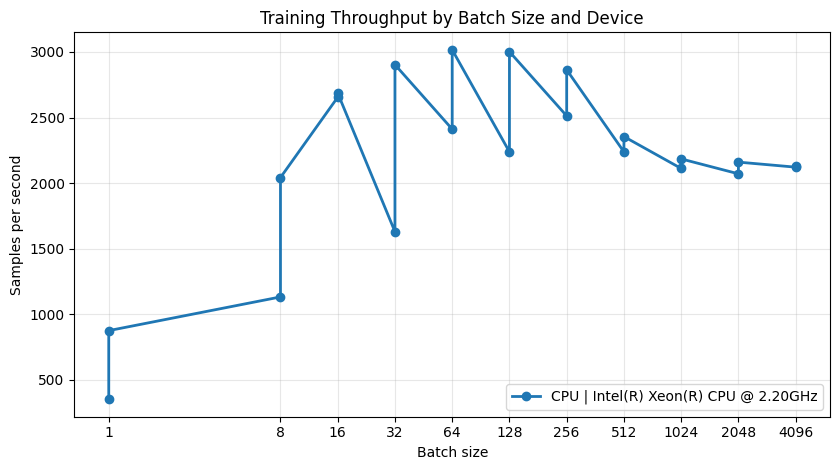

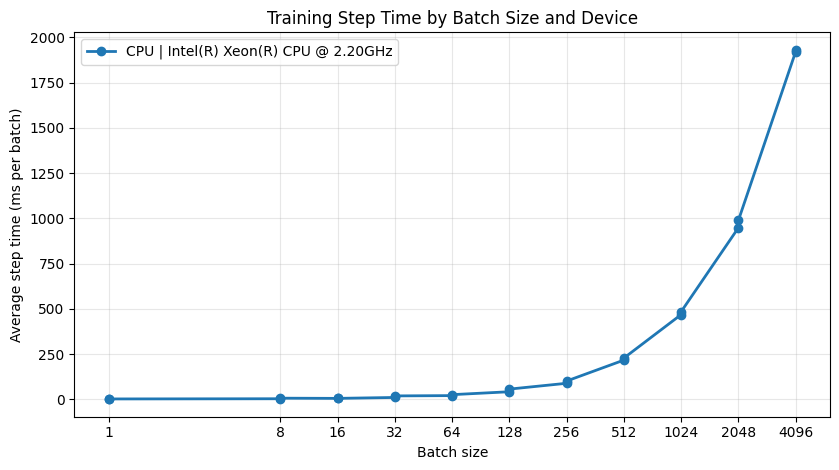

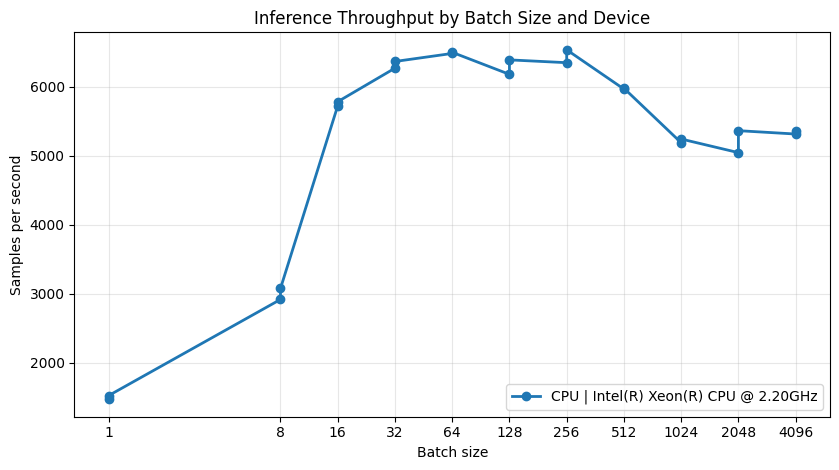

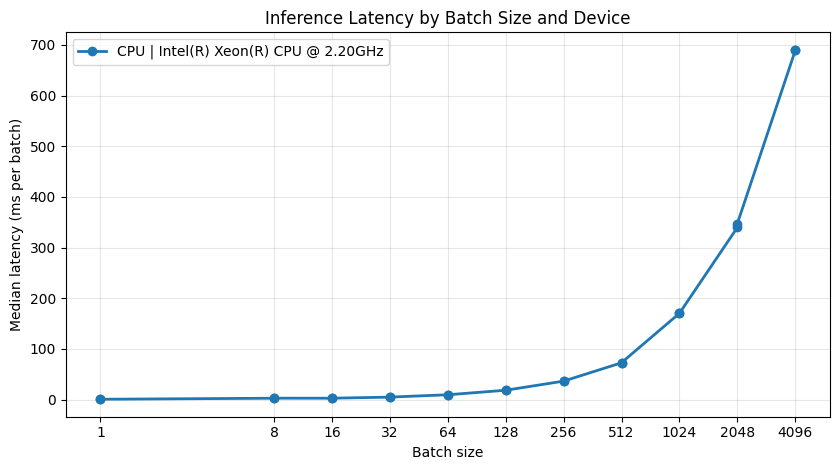

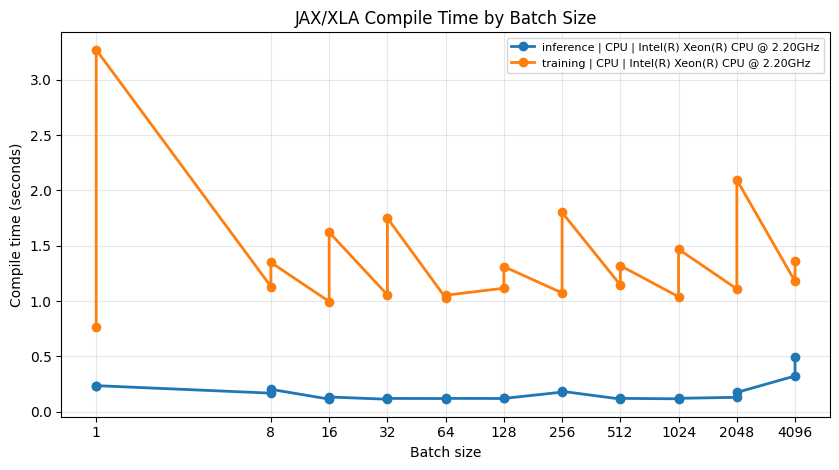

In [7]:
def load_csv_rows(path: pathlib.Path) -> List[Dict[str, str]]:
    if not path.exists():
        return []
    with path.open("r", newline="") as handle:
        return list(csv.DictReader(handle))


def to_float(value: Any) -> float:
    try:
        result = float(value)
        return result
    except Exception:
        return math.nan


def to_int(value: Any) -> int:
    try:
        return int(float(value))
    except Exception:
        return 0


def compact_hardware_name(name: str, max_len: int = 46) -> str:
    text = name.replace("NVIDIA ", "").replace("Google ", "")
    return text if len(text) <= max_len else text[:max_len - 3] + "..."


def device_label(row: Dict[str, Any]) -> str:
    return f"{row.get('device_type', 'unknown')} | {compact_hardware_name(row.get('hardware_model', 'unknown'))}"


def successful_rows(rows: Iterable[Dict[str, Any]], task_type: Optional[str] = None) -> List[Dict[str, Any]]:
    selected = []
    for row in rows:
        if row.get("status") != "success":
            continue
        if task_type is not None and row.get("task_type") != task_type:
            continue
        selected.append(row)
    return selected


def plot_metric_by_batch(rows: List[Dict[str, Any]], task_type: str, metric: str, ylabel: str, title: str) -> None:
    task_rows = successful_rows(rows, task_type)
    if not task_rows:
        print(f"No successful {task_type} rows available for {title}.")
        return

    grouped: Dict[str, List[Tuple[int, float]]] = {}
    for row in task_rows:
        x = to_int(row.get("batch_size"))
        y = to_float(row.get(metric))
        if x > 0 and not math.isnan(y):
            grouped.setdefault(device_label(row), []).append((x, y))

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for label, points in sorted(grouped.items()):
        points = sorted(points)
        ax.plot([point[0] for point in points], [point[1] for point in points], marker="o", linewidth=2, label=label)

    ax.set_title(title)
    ax.set_xlabel("Batch size")
    ax.set_ylabel(ylabel)
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted({to_int(row.get("batch_size")) for row in task_rows if to_int(row.get("batch_size")) > 0}))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


def plot_compile_overhead(rows: List[Dict[str, Any]]) -> None:
    task_rows = successful_rows(rows)
    if not task_rows:
        print("No successful rows available for compile overhead chart.")
        return

    grouped: Dict[str, List[Tuple[int, float]]] = {}
    for row in task_rows:
        x = to_int(row.get("batch_size"))
        y = to_float(row.get("compile_time_seconds"))
        if x > 0 and not math.isnan(y):
            label = f"{row.get('task_type', 'task')} | {device_label(row)}"
            grouped.setdefault(label, []).append((x, y))

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for label, points in sorted(grouped.items()):
        points = sorted(points)
        ax.plot([point[0] for point in points], [point[1] for point in points], marker="o", linewidth=2, label=label)

    ax.set_title("JAX/XLA Compile Time by Batch Size")
    ax.set_xlabel("Batch size")
    ax.set_ylabel("Compile time (seconds)")
    ax.set_xscale("log", base=2)
    ax.set_xticks(sorted({to_int(row.get("batch_size")) for row in task_rows if to_int(row.get("batch_size")) > 0}))
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    plt.show()


ALL_ROWS = load_csv_rows(ALL_RESULTS_PATH)
print(f"Loaded {len(ALL_ROWS)} rows from {ALL_RESULTS_PATH}")

plot_metric_by_batch(
    ALL_ROWS,
    "training",
    "throughput_samples_per_second",
    "Samples per second",
    "Training Throughput by Batch Size and Device",
)
plot_metric_by_batch(
    ALL_ROWS,
    "training",
    "average_latency_ms",
    "Average step time (ms per batch)",
    "Training Step Time by Batch Size and Device",
)
plot_metric_by_batch(
    ALL_ROWS,
    "inference",
    "throughput_samples_per_second",
    "Samples per second",
    "Inference Throughput by Batch Size and Device",
)
plot_metric_by_batch(
    ALL_ROWS,
    "inference",
    "median_latency_ms",
    "Median latency (ms per batch)",
    "Inference Latency by Batch Size and Device",
)
plot_compile_overhead(ALL_ROWS)

## Optional Cost-Efficiency Chart

If you know your hourly prices, fill in `HOURLY_COST_USD_BY_DEVICE_LABEL` below. Prices vary by region, reservation, spot/preemptible settings, and date, so this notebook does not hard-code prices.

Use labels printed by `device_label(row)` in the previous section, or inspect `benchmark_results_all.csv`.

In [8]:
HOURLY_COST_USD_BY_DEVICE_LABEL = {
    # Example:
    # "GPU | H100 80GB HBM3": 8.00,
    # "TPU | TPU v5e": 1.20,
    # "CPU | Intel(R) Xeon(R) ...": 0.30,
}


def plot_cost_efficiency(rows: List[Dict[str, Any]], hourly_costs: Dict[str, float], task_type: str) -> None:
    task_rows = successful_rows(rows, task_type)
    points = []
    for row in task_rows:
        label = device_label(row)
        hourly_cost = hourly_costs.get(label)
        throughput = to_float(row.get("throughput_samples_per_second"))
        if hourly_cost and throughput > 0:
            samples_per_dollar = throughput * 3600.0 / hourly_cost
            points.append((label, to_int(row.get("batch_size")), samples_per_dollar))

    if not points:
        print(f"Cost-efficiency chart skipped for {task_type}; provide hourly costs to enable it.")
        return

    labels = [f"{label}\nbs={batch_size}" for label, batch_size, _ in points]
    values = [value for _, _, value in points]
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    ax.bar(range(len(values)), values)
    ax.set_title(f"{task_type.title()} Cost Efficiency")
    ax.set_ylabel("Samples per dollar")
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.grid(True, axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_cost_efficiency(ALL_ROWS, HOURLY_COST_USD_BY_DEVICE_LABEL, "training")
plot_cost_efficiency(ALL_ROWS, HOURLY_COST_USD_BY_DEVICE_LABEL, "inference")

Cost-efficiency chart skipped for training; provide hourly costs to enable it.
Cost-efficiency chart skipped for inference; provide hourly costs to enable it.


## Summary Table

The summary table reports the best throughput row for each task and device label. It is most useful after you have combined CPU, GPU, and TPU CSV rows.

In [9]:
def markdown_table(headers: List[str], rows: List[List[str]]) -> str:
    header_line = "| " + " | ".join(headers) + " |"
    separator = "| " + " | ".join(["---"] * len(headers)) + " |"
    body = ["| " + " | ".join(row) + " |" for row in rows]
    return "\n".join([header_line, separator] + body)


def build_summary_table(rows: List[Dict[str, Any]]) -> str:
    grouped: Dict[Tuple[str, str], List[Dict[str, Any]]] = {}
    for row in successful_rows(rows):
        key = (row.get("task_type", "unknown"), device_label(row))
        grouped.setdefault(key, []).append(row)

    summary_rows = []
    for (task_type, label), group in sorted(grouped.items()):
        best = max(group, key=lambda row: to_float(row.get("throughput_samples_per_second")))
        latency_values = [to_float(row.get("median_latency_ms")) for row in group if not math.isnan(to_float(row.get("median_latency_ms")))]
        best_latency = min(latency_values) if latency_values else math.nan
        summary_rows.append(
            [
                task_type,
                label,
                str(best.get("batch_size")),
                f"{to_float(best.get('throughput_samples_per_second')):.2f}",
                f"{best_latency:.3f}",
                f"{to_float(best.get('compile_time_seconds')):.3f}",
                best.get("hardware_generation_note", ""),
            ]
        )

    if not summary_rows:
        return "No successful benchmark rows are available yet."

    return markdown_table(
        [
            "Task",
            "Device",
            "Best batch size",
            "Best throughput",
            "Best median latency ms",
            "Compile seconds at best throughput",
            "Generation note",
        ],
        summary_rows,
    )


summary = build_summary_table(ALL_ROWS)
try:
    from IPython.display import Markdown, display

    display(Markdown(summary))
except Exception:
    print(summary)

| Task | Device | Best batch size | Best throughput | Best median latency ms | Compile seconds at best throughput | Generation note |
| --- | --- | --- | --- | --- | --- | --- |
| inference | CPU | Intel(R) Xeon(R) CPU @ 2.20GHz | 256 | 6533.30 | 0.644 | 0.185 | CPU baseline: useful for correctness and scale reference, not an accelerator peer. |
| training | CPU | Intel(R) Xeon(R) CPU @ 2.20GHz | 64 | 3016.70 | 1.137 | 1.053 | CPU baseline: useful for correctness and scale reference, not an accelerator peer. |

## Interpretation Guide

Use these results carefully:

1. TPU/GPU comparison depends on workload. A small CNN on Fashion-MNIST is not the same as a large ResNet, LLM, recommender, or diffusion workload.
2. Training and inference results should not be mixed. Training includes backpropagation and optimizer updates; inference is forward-only.
3. Batch size changes the story. Larger batches can improve throughput by filling the accelerator, but may increase per-batch latency and memory usage.
4. JAX/XLA compile time matters. TPU and GPU runs can show noticeable first-run or compile overhead. For long jobs this overhead may be amortized; for short jobs it can dominate.
5. CPU is a baseline for correctness and scale intuition. It should not be treated as an equivalent accelerator.
6. Hardware generation must be labeled. H100 is a generation-aligned GPU baseline for TPU v5e. A100 is useful when H100 is unavailable, but should be labeled as a practical fallback. P100 and V100 should be treated as historical or available-school baselines, not generation-aligned baselines.
7. Software stack maturity matters. GPU performance may benefit from mature CUDA libraries and framework kernels. TPU performance depends heavily on XLA compilation and shapes that map well to TPU execution.
8. Precision matters. This notebook defaults to float32 for simplicity. Real MLPerf submissions often use carefully validated lower precision such as bfloat16 or float16.
9. Small mini benchmarks should not be overgeneralized to full-scale MLPerf. They are useful for teaching concepts, identifying bottlenecks, and practicing measurement discipline.

## Suggested Next Steps

1. Run CPU first and save the CSV files.
2. Run TPU v5e with the same batch sizes and iteration counts.
3. Run H100 only after the workflow is validated. Start with `expanded`, then use `accelerator_stress` if budget and quota allow it.
4. Combine the CSV files and re-run the visualization cells.
5. Add current hourly prices to the optional cost-efficiency section.
6. Try an explicitly labeled bfloat16 experiment and compare compile time, throughput, and accuracy behavior.
7. Increase measured iterations only if your budget and quota allow it.
8. For deeper study, replace Fashion-MNIST with CIFAR-10 or a small transformer-like workload while keeping the same logging schema.